In [4]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph.message import add_messages
from typing import Optional, TypedDict, Annotated

C:\Users\harsh\AppData\Local\Temp\ipykernel_15344\1610577545.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [5]:
load_dotenv()

True

In [6]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [7]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2-preview", 
    output_dimensionality=768
)

In [8]:
docs= (PyPDFLoader("./research-paper/doc.pdf").load())

In [9]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size= 1000, chunk_overlap=200).split_documents(docs)

In [10]:
vectorstore = FAISS.from_documents(chunks, embeddings)

GoogleGenerativeAIError: Error embedding content (UNAUTHENTICATED): 401 UNAUTHENTICATED. {'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.', 'status': 'UNAUTHENTICATED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'ACCESS_TOKEN_TYPE_UNSUPPORTED', 'metadata': {'method': 'google.ai.generativelanguage.v1beta.GenerativeService.BatchEmbedContents', 'service': 'generativelanguage.googleapis.com'}}]}}

In [ ]:
vectorstore

NameError: name 'vectorstore' is not defined

In [25]:
from typing import Literal

class State(TypedDict):
    query: str
    needs_retrieval: Annotated[bool, "Whether the query needs retrieval or not."]

    docs: list[Document]
    relevant_docs: list[Document]

    answer: str
    context: str
    is_support: Literal["full_support", "partial_support", "no_support"]

    retries: int
    is_useful_to_answer_query: bool

In [26]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

NameError: name 'vectorstore' is not defined

In [27]:
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

class RetrieveDecision(BaseModel):
    needs_retrieval: bool = Field(..., description="Whether the query needs retrieval or not.")

retrieval_decision_prompt = """You decide whether the query needs retrieval or not. 
If the query is related to the research paper, you should set needs_retrieval to True, Something
not in parametric Knowledge of LLM, and only present in the Research Paper. 
Otherwise, set it to False.
"""

retrieval_decider = llm.with_structured_output(RetrieveDecision)
def retrieval_decision_node(state:State):
    response = retrieval_decider.invoke([SystemMessage(content=retrieval_decision_prompt), HumanMessage(content=state["query"])])
    return {"needs_retrieval": response.needs_retrieval}


In [28]:
direct_answer_prompt = ChatPromptTemplate.from_messages([
    ("system" , 
     """
Answer the question based on your parametric knowledge. If you don't know the answer, say "I don't know".
Do NOT assume access to external sources or the research paper. Only use your own knowledge to answer the question.
"""),
("human" , "{query}")])

In [29]:
def direct_answer_node(state:State):
    prompt = direct_answer_prompt.format_prompt(query=state["query"])
    response = llm.invoke(prompt)
    return {"answer": response.content, "context": ""}

In [30]:
def retrieval_node(state:State):
    docs = retriever.invoke(state["query"])
    return {"docs": docs}

In [31]:
def route_after_retrieval_decision(state:State):
    if state["needs_retrieval"]:
        return "retrieval_node"
    else:
        return "direct_answer_node"

In [32]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(..., description="True if the document helps answer the question, else False")

In [33]:
RELEVANCE_DECISION_PROMPT = """You are given a question and a document. You need to decide whether the document is relevant to the question or not.
If the document helps answer the question, set is_relevant to True. Otherwise, set it
to False.
"""

In [34]:
def relevance_decision_node(state:State):
    query = state["query"]
    docs = state["docs"]
    relevance_decider = llm.with_structured_output(RelevanceDecision)
    relevant_docs : list[Document] = []
    for doc in docs:
        prompt = ChatPromptTemplate.from_messages([
            ("system", RELEVANCE_DECISION_PROMPT),
            ("human", f"Question: {query}\nDocument: {doc.page_content}")
        ]).format_prompt()
        
        response = relevance_decider.invoke(prompt)
        if response.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

In [35]:
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
        """
You are a Research RAG Assistant. You are given a question and a set of documents. You need to answer the question based on the documents.
If the documents do not contain enough information to answer the question, say "I don't know".
Do NOT use your parametric knowledge to answer the question. Only use the documents to answer the question.
"""),
    ("human", "{query}"),
    ("human", "Documents: {context}")
])

In [36]:
def generate_from_rag(state:State):
    context= [doc.page_content for doc in state["relevant_docs"]].join("\n\n")
    if not context:
        return {"answer": "I don't know", "context": ""}
    prompt = RAG_PROMPT.format_prompt(query=state["query"], context=context)
    response = llm.invoke(prompt)
    return {"answer": response.content, "context": context}

In [37]:
def no_relevant_docs_node(state:State):
    return {"answer": "I don't know", "context": ""}

In [38]:
def route_after_relevance_decision(state:State):
    if state["relevant_docs"] and len(state["relevant_docs"]) > 0:
        return "generate_from_rag"
    else:
        return "no_relevant_docs_node"

In [39]:
class IsSupportDecision(BaseModel):
    is_support: Literal["full_support", "partial_support", "no_support"] = Field(..., description="Whether the Retrieved documents fully supports, partially supports, or does not support the answer.")

In [40]:
SUPPORT_DECISION_PROMPT = """
You are an evidence-verification evaluator in a Retrieval-Augmented Generation (RAG) system.
Your task is to determine how well the generated answer is supported by the provided context,
while also checking whether it answers the query.

You will receive three inputs:
1. Query: The original question or query that was asked.
2. Answer: The answer generated by the RAG system.
3. Context: The retrieved documents or information that the answer is based on.

Evaluate the generated answer using the following rules:

1. Compare the answer directly with the query.
   Determine what claims are required to answer the query and whether the answer addresses them.

2. Compare every factual claim in the answer with the context.
   The context is the only permitted source of evidence. Do not use your parametric knowledge,
   outside information, or assumptions to fill gaps in the context.

3. Treat an answer as fully supported only when:
   - the answer directly addresses the query;
   - all important factual claims are explicitly supported by the context; and
   - the answer does not introduce unsupported details, contradictions, or unjustified conclusions.

4. Treat an answer as partially supported when:
   - the answer addresses the query and at least one important claim is supported by the context,
     but one or more important claims are missing evidence, overstated, or unsupported; or
   - the context supports only part of the answer or only part of what the query asks.

5. Treat an answer as having no support when:
   - the context does not provide evidence for the answer;
   - the answer contradicts the context;
   - the answer is unrelated to the query; or
   - the context is empty, irrelevant, or insufficient to verify any meaningful part of the answer.

Additional instructions:
- Judge support, not writing quality, fluency, or completeness alone.
- A correct answer based only on general knowledge is still `no_support` if the context does not support it.
- If the answer says "I don't know" because the context is insufficient, classify it as `full_support`
  when that limitation is an appropriate conclusion from the context; otherwise classify it according
  to the evidence available.
- Do not reward citations or confident wording unless the cited claims are actually supported by the context.
- Resolve the decision conservatively: unsupported factual claims must not be treated as supported.

Return only a structured result that conforms exactly to the `IsSupportDecision` Pydantic schema.
The `is_support` value must be exactly one of:
- `full_support`
- `partial_support`
- `no_support`
"""

In [41]:
def support_decision_node(state:State):
    prompt = ChatPromptTemplate.from_messages([
        ("system", SUPPORT_DECISION_PROMPT),
        ("human", "Query: {query}"),
        ("human", "Answer: {answer}"),
        ("human", "Context: {context}")
    ]).format_prompt(query=state["query"], answer=state["answer"], context=state["context"])
    
    support_decider = llm.with_structured_output(IsSupportDecision)
    response = support_decider.invoke(prompt)
    return {"is_support": response.is_support}

In [42]:
REVISE_SYSTEM_PROMPT = """
You are a grounded-response revision assistant.
The Previous Answer is not fully supported by the context. Your task is to revise the answer to be fully supported by the context.
You will receive three inputs:
1. Query: The original question or query that was asked.
2. Previous Answer: The answer generated by the RAG system that is not fully supported by the context.
3. Context: The retrieved documents or information that the answer is based on.
Your task is to produce a revised answer to the QUERY using only the information explicitly stated in the CONTEXT.

Rules:
1. Answer the QUERY directly and concisely.
2. Use only facts, wording, and conclusions supported by the CONTEXT.
3. Do not use parametric knowledge, assumptions, inference, speculation, or outside information.
4. Do not add explanations, examples, introductions, conclusions, citations, or commentary that are not supported by the CONTEXT.
5. Do not mention the CONTEXT, the revision process, grounding, documents, or these instructions.
6. Preserve the meaning of supported information without exaggerating or changing it.
7. If the CONTEXT does not contain enough information to answer the QUERY, return exactly:
Not in docs
8. Return only the answer text. Do not return labels, formatting, reasoning, or any additional words.
"""

In [43]:
def revise_answer_node(state:State):
    prompt = ChatPromptTemplate.from_messages([
        ("system", REVISE_SYSTEM_PROMPT),
        ("human", "QUERY: {query}"),
        ("human", "CONTEXT: {context}"),
        ("human", "PREVIOUS ANSWER: {answer}")
    ]).format_prompt(query=state["query"], context=state["context"], answer=state["answer"])
    
    response = llm.invoke(prompt)
    revised_answer = response.text.strip()
    
    return {"answer" : revised_answer, "retries" : state.get("retries", 0) + 1}

In [44]:
class IsUseDecision(BaseModel):
    is_useful_to_answer_query: bool = Field(..., description="Whether the answer is useful to answer the query or not.")

In [45]:
IS_USEFUL_TO_ANSWER_QUERY_PROMPT = """
You are an evaluator in a Retrieval-Augmented Generation (RAG) system.

Your task is to determine whether the generated Answer is useful for answering the original Query.

You will receive two inputs:

1. Query: The original user question.
2. Answer: The answer generated by the RAG system.

Evaluate usefulness based on the following criteria:

- The Answer directly addresses the Query.
- The Answer provides information relevant to what the user asked.
- The Answer is sufficiently complete to be useful.
- The Answer is understandable and does not consist primarily of irrelevant content.
- The Answer does not merely repeat the question.
- The Answer does not refuse to answer without a valid reason.

Set `is_useful_to_answer_query` to `True` when the Answer provides a meaningful response to the Query, even if it is concise or only partially answers a multi-part question.

Set `is_useful_to_answer_query` to `False` when:

- The Answer is unrelated to the Query.
- The Answer does not address the main request.
- The Answer is empty, incoherent, or evasive.
- The Answer says "I don't know", "Not in docs", or an equivalent phrase without providing any useful answer.
- The Answer contains only unsupported generic statements that do not help answer the Query.

Judge usefulness and relevance only. Do not independently verify whether the Answer is factually correct or fully supported by the documents.

Return only a structured result conforming exactly to the `IsUseDecision` Pydantic schema:

{
    "is_useful_to_answer_query": true or false
}
"""

In [46]:
is_useful_decider = llm.with_structured_output(IsUseDecision)

def is_useful_to_answer_query_node(state:State):
    prompt = ChatPromptTemplate.from_messages([
        ("system", IS_USEFUL_TO_ANSWER_QUERY_PROMPT),
        ("human", "Query: {query}"),
        ("human", "Answer: {answer}")
    ]).format_prompt(query=state["query"], answer=state["answer"])
    
    response: IsUseDecision = is_useful_decider.invoke(prompt)
    return {"is_useful_to_answer_query": response.is_useful_to_answer_query}

In [48]:
def route_for_revise(state:State):
    if state['is_support'] == "full_support":
        return 'is_useful_to_answer_query_node'
    elif state.get("retries", 0) < 5:
        return "revise_answer_node"
    else:
        return "no_relevant_docs_node"

In [53]:
def route_after_usefulness_decision(state:State):
    if state['is_useful_to_answer_query']:
        return END
    else:
        return "no_relevant_docs_node"

In [54]:
g = StateGraph(State)
#add nodes
g.add_node("retrieval_decision_node", retrieval_decision_node)
g.add_node("retrieval_node", retrieval_node)
g.add_node("relevance_decision_node", relevance_decision_node)
g.add_node("generate_from_rag", generate_from_rag)
g.add_node("no_relevant_docs_node", no_relevant_docs_node)
g.add_node("direct_answer_node", direct_answer_node)
g.add_node("support_decision_node", support_decision_node)
g.add_node("revise_answer_node", revise_answer_node)
g.add_node("is_useful_to_answer_query_node", is_useful_to_answer_query_node)

In [55]:
#add edges
g.add_edge(START, "retrieval_decision_node")
g.add_conditional_edges("retrieval_decision_node", route_after_retrieval_decision)
g.add_edge("direct_answer_node", END)
g.add_edge("retrieval_node", 'relevance_decision_node')
g.add_conditional_edges("relevance_decision_node", route_after_relevance_decision)
g.add_edge("generate_from_rag", 'support_decision_node')
g.add_edge('revise_answer_node', 'support_decision_node')
g.add_conditional_edges("support_decision_node", route_for_revise)
g.add_edge("no_relevant_docs_node", END)
g.add_conditional_edges("is_useful_to_answer_query_node", route_after_usefulness_decision)

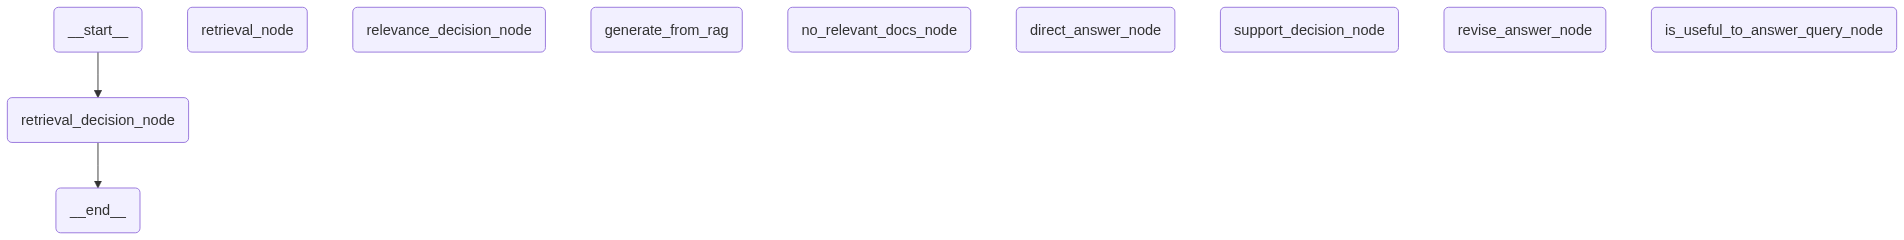

In [52]:
workflow = g.compile()
workflow

In [45]:
query = "What is full form of AI"
response = workflow.invoke({"query": query})
response

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'query': 'What is full form of AI',
 'needs_retrieval': False,
 'answer': [{'type': 'text',
   'text': 'The full form of AI is **Artificial Intelligence**.',
   'extras': {'signature': 'EmAKXgFpFH0TOAUVCC5ZS+sPt3PuYpP3gaaoKT3JYig5cR19D42+92joEjWicJUn5XuCcQNMT7lRqzBBvAN/4rDbDigEzBPar3K3Qm3urd/wUjwtI3lDxj7Y3pZTzX05upY='}}],
 'context': ''}

In [52]:
query = "What is the main contribution of the research paper?"
response = workflow.invoke({"query": query})
response

NameError: name 'retriever' is not defined

In [1]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(..., description="True if the document helps answer the question, else False")

NameError: name 'BaseModel' is not defined